In [4]:
import os
import sys
import matplotlib.pyplot as plt
import rasterio
import numpy as np
import glob
import cv2
from pathlib import Path
import tifffile as tiff

from rasterio.warp import Resampling, reproject
from matplotlib.colors import ListedColormap, BoundaryNorm

In [ ]:
# Jayden paths are listed in code: 
# out_folder = "C:/Users/jaydb/Snowpack_Project/Super_imposed_Images"
OUT_FOLDER_SUPER_IMPOSED = Path("C:/Users/jaydb/Snowpack_Project/Super_imposed_Images")
# source_data_dir = "C:/Users/jaydb/Snowpack_Project/2019-2020_Data/Imagery/"
# updated to:
IMAGERY_FOLDER = Path("C:/Users/jaydb/Snowpack_Project/2019-2020_Data/Imagery/")


In [ ]:
# Directory paths for Joel's OneDrive setup
ONEDRIVE_BASE = Path("/Users/joelcarlson/Library/CloudStorage/OneDrive-SharedLibraries-UCB-O365/Travis Hainsworth - RMBL")
SOURCE_FILEPATH = Path(ONEDRIVE_BASE / "2 - Source Data" / "2019-2020_Data")
IMAGERY_FOLDER = Path(SOURCE_FILEPATH / "Imagery")

# Global file locations: Super_imposed_Images
OUT_FOLDER_SUPER_IMPOSED =  Path(SOURCE_FILEPATH / "Super_imposed_Images")

In [2]:
def get_tiff_widths(directories, source_data_dir):
    """
    Given a list of directories, find all .tif or .tiff files
    and return a list of (filename, width) tuples.
    """
    tiff_files = []
    for directory in directories:
        counter = 1
        final_directory = source_data_dir + directory
        for root, dirs, files in os.walk(final_directory):
            for f in files:
                if f.lower().endswith(('.tif', '.tiff')):
                    tiff_files.append((directory + str(counter), os.path.join(root, f)))
                    counter += 1
                    
    widths = []
    for tiff_path in tiff_files:
        with rasterio.open(tiff_path[1]) as src:
            width = src.width
            height = src.height
            
            if (width >= height):
                widths.append((tiff_path[0] + "width", width))
            else:
                widths.append((tiff_path[0] + "Height", height))
                              
    return widths

In [3]:
def plot_widths(widths, directory):
    """
    Given a list of (filename, width) tuples, plot the widths.
    """
    # Sort by width or just keep as is:
    widths_sorted = sorted(widths, key=lambda x: x[1])
    
    # Extract filenames and values
    filenames = [os.path.basename(w[0]) for w in widths_sorted]
    values = [w[1] for w in widths_sorted]

    plt.figure(figsize=(10, 6))
    plt.barh(filenames, values)
    plt.xlabel('Width (pixels)')
    plt.ylabel('File')
    plt.title(directory + ' TIFF Image Widths')
    plt.show()

In [10]:
def visualize_nodata_and_nan(tiff_path, band_index=1):
    """
    Visualize which pixels in a single-band TIFF are:
      - "ordinary data"   => code 0
      - "nodata"          => code 1
      - actual NaN        => code 2

    Args:
      tiff_path   : path to your GeoTIFF
      band_index  : which band to read (1-based index)
    """
    if not os.path.exists(tiff_path):
        print(f"File not found: {tiff_path}")
        return

    # 1) Open TIFF
    with rasterio.open(tiff_path) as src:
        nodata_val = src.nodata
        print(f"Opened {tiff_path}")
        print(f" nodata: {nodata_val}")

        # 2) Read band as float32 with no auto-masking
        arr = src.read(band_index, masked=False).astype(np.float32)

    # 3) Create an integer array to label each pixel
    h, w = arr.shape
    label_arr = np.full((h, w), -1, dtype=np.int8)

    # Mark actual NaNs as code=2
    # note: np.isnan(...) returns a boolean array
    is_nan = np.isnan(arr)
    label_arr[is_nan] = 2

    # If nodata is not None, mark those pixels as code=1
    # skip if nodata_val is None
    if nodata_val is not None:
        # For safety, we can use np.isclose if nodata_val is big or floating
        is_nodata = np.isclose(arr, nodata_val, atol=1e-5)
        # Also exclude those that are already NaN
        is_nodata = is_nodata & (~is_nan)
        label_arr[is_nodata] = 1

    # Everything else => code=0 (valid data)
    # So if label_arr is still -1, assign 0
    label_arr[label_arr == -1] = 0

    # 4) Create a discrete colormap:
    #   0 => valid data (blue)
    #   1 => nodata (red)
    #   2 => NaN (gray)
    cmap = ListedColormap(["blue", "red", "gray"])
    # We want the boundaries: -0.5, 0.5 => color0, 1.5 => color1, 2.5 => color2, etc.
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

    # 5) Plot
    plt.figure(figsize=(8, 6))
    plt.title(f"Nodata/NaN Visualization\n{os.path.basename(tiff_path)} (band={band_index})")
    im = plt.imshow(label_arr, cmap=cmap, norm=norm)
    plt.axis('off')

    # Add colorbar
    cbar = plt.colorbar(im, ticks=[0,1,2])
    cbar.ax.set_yticklabels(["valid data(0)", "nodata(1)", "NaN(2)"])

    plt.tight_layout()
    plt.show()


def debug_tile_pair(img_tile_path, msk_tile_path):
    """
    Loads a single tile's image (Numpy .npy) and mask (Numpy .npy),
    then prints out relevant statistics to help diagnose whether this
    tile is suitable for U-Net training.

    1) Image tile:
       - shape, channels-first vs. channels-last
       - min/max/mean
       - number of NaN
    2) Mask tile:
       - shape
       - count of 0, 1, NaN, and -3.4e38
       - valid ratio ( fraction of [0 or 1] / total pixels )
    """
    if not os.path.exists(img_tile_path):
        print(f"Image tile not found: {img_tile_path}")
        return
    if not os.path.exists(msk_tile_path):
        print(f"Mask tile not found: {msk_tile_path}")
        return

    # -- Load them --
    img_tile = np.load(img_tile_path)
    msk_tile = np.load(msk_tile_path)

    print(f"\n=== Analyzing tile pair ===")
    print(f"Image tile path: {img_tile_path}")
    print(f"Mask tile path : {msk_tile_path}")

    # ---------- IMAGE TILE ----------
    print("\n--- Image Tile ---")
    print("raw shape:", img_tile.shape)

    # Check channels-first vs. channels-last
    # For a tile of size (512,512) with 4 channels:
    #   - channels-first shape => (4,512,512)
    #   - channels-last  shape => (512,512,4)
    # We can guess which scenario it is by looking at the shape.
    if len(img_tile.shape) == 3:
        c0, c1, c2 = img_tile.shape
        # Heuristic
        if c0 in [3,4] and (c1 == 512) and (c2 == 512):
            print("Detected channels-first format (C,H,W).")
        elif (c0 == 512) and (c1 == 512) and c2 in [3,4]:
            print("Detected channels-last format (H,W,C).")
        else:
            print("Unknown 3D shape, might be partial coverage or something else.")
    elif len(img_tile.shape) == 2:
        print("Detected single-band 2D image tile.")
    else:
        print("Unexpected image shape. Possibly a multi-band tile with shape:", img_tile.shape)

    # Basic stats
    # Flatten ignoring any potential masked structure for now
    flat_img = img_tile.ravel().astype(np.float32)
    # Count how many are NaN
    img_nans = np.count_nonzero(np.isnan(flat_img))
    # min, max, mean ignoring NaN:
    valid_pixels = flat_img[~np.isnan(flat_img)]
    img_min = np.min(valid_pixels) if valid_pixels.size else float('nan')
    img_max = np.max(valid_pixels) if valid_pixels.size else float('nan')
    img_mean = np.mean(valid_pixels) if valid_pixels.size else float('nan')

    print(f"image tile stats =>  #NaN={img_nans}, min={img_min}, max={img_max}, mean={img_mean}")

    # ---------- MASK TILE ----------
    print("\n--- Mask Tile ---")
    print("raw shape:", msk_tile.shape)

    # Flatten
    flat_mask = msk_tile.ravel()

    # Count how many are exactly 0, 1, nan, or -3.4e38
    # Note: for floating arrays, use np.isclose or np.isnan
    mask_zeros   = np.count_nonzero(np.isclose(flat_mask, 0))
    mask_ones    = np.count_nonzero(np.isclose(flat_mask, 1))
    mask_nan     = np.count_nonzero(np.isnan(flat_mask))
    # If the tile is float32, let's do an atol
    # to catch -3.4e38 within a small tolerance:
    mask_neg_ext = np.count_nonzero(np.isclose(flat_mask, -3.4e38, atol=1e-4))

    # Valid ratio => fraction of [0 or 1] vs total
    # total = flat_mask.size
    # valid = mask_zeros + mask_ones
    total_pixels  = flat_mask.size
    valid_pixels  = mask_zeros + mask_ones
    valid_ratio   = valid_pixels / total_pixels if total_pixels>0 else 0

    print(f"mask stats => total={total_pixels}, #NaN={mask_nan}, #-3.4e38={mask_neg_ext}")
    print(f"             #zeros={mask_zeros}, #ones={mask_ones}, valid_ratio={valid_ratio:.4f}")

    # If you want, you could also check for any other values besides 0,1,nan
    # For instance:
    unique_vals = np.unique(flat_mask[~np.isnan(flat_mask)])
    # We'll remove -3.4e38 from the unique listing if it is present
    unique_vals = unique_vals[~np.isclose(unique_vals, -3.4e38, atol=1e-4)]
    print("unique mask values (excluding NaN/-3.4e38):", unique_vals)

    # ---------- Summary Info ----------
    print("\n--- Summary ---")
    # For example, "Looks good" if valid_ratio is 1.0
    if valid_ratio == 1.0:
        print("Mask has 100% valid [0 or 1]. No NaNs or weird values found in the mask.")
    else:
        print(f"Mask has {valid_ratio*100:.2f}% valid [0 or 1]. Some invalid or NaN pixels exist.")

    # If image tile has a lot of NaNs, note it
    if img_nans > 0:
        perc_nans = (img_nans / flat_img.size)*100
        print(f"WARNING: Image tile has {perc_nans:.2f}% NaNs.")
    else:
        print("No NaNs in the image tile array.")

    print("Done.\n")

In [18]:
def list_nodata_in_all_subfolders(base_mask_folder, mask_pattern="*_snowbinary.tif"):
    """
    Loops through subfolders (locations) under `base_mask_folder`,
    finds all TIF mask files matching `mask_pattern`,
    and prints their nodata status.

    Args:
      base_mask_folder (str): The root folder containing subfolders (one per location).
      mask_pattern (str): Filename pattern for mask TIFFs, default is '*_snowbinary.tif'.
    """
    # 1) Collect all subfolders in base_mask_folder
    subfolders = [f for f in os.listdir(base_mask_folder)
                  if os.path.isdir(os.path.join(base_mask_folder, f))]

    # 2) For each subfolder, gather TIF files matching the pattern
    for location_name in subfolders:
        location_path = os.path.join(base_mask_folder, location_name)
        mask_files = glob.glob(os.path.join(location_path, mask_pattern))
        if not mask_files:
            print(f"[{location_name}] No files match '{mask_pattern}'")
            continue

        print(f"\n=== Location: {location_name} ===")
        for mask_file in mask_files:
            # 3) Open with rasterio and check nodata
            try:
                with rasterio.open(mask_file) as src:
                    nd = src.nodata
                basefile = os.path.basename(mask_file)
                if nd is None:
                    print(f"  {basefile}: nodata=None (no nodata set)")
                    
                else:
                    print(f"  {basefile}: nodata={nd}")
            except Exception as e:
                print(f"  ERROR reading {mask_file}: {e}")

In [ ]:
def read_tiff_rasterio(tiff_path):
    """
    Read all bands of a TIFF into a float32 np.array of shape (C, H, W).
    Returns:
        data (np.ndarray): shape (C,H,W), float32
        profile (dict)   : rasterio's metadata profile
    """
    with rasterio.open(tiff_path) as src:
        profile = src.profile
        bands_list = []
        for i in range(1, src.count + 1):
            band_data = src.read(i).astype(np.float32)
            bands_list.append(band_data)
        data = np.stack(bands_list, axis=0)
    return data, profile


def visualize_tif_image_and_mask(
    image_tif_path,
    mask_tif_path,
    title="Image + Mask Overlay",
    do_resample=True,
    mask_alpha=0.4
):
    """
    1) Reads image_tif_path (3 or 4 bands) using rasterio.
    2) Reads mask_tif_path (assumed 1 band).
    3) If shapes differ, optionally resample (upscale/downscale) mask to match image.
    4) Plots:
       - Left subplot: if there's a 4th alpha band, show it separately.
       - Right subplot: color image (RGB) with mask overlaid in red.
    5) Saves the composite (mask overlay) image as a TIFF in the folder "super_imposed_images".

    Args:
        image_tif_path (str): Path to the main image (RGB or RGBA).
        mask_tif_path (str): Path to the binary mask (1 band).
        title (str): Figure title for the overlay plot.
        do_resample (bool): Whether to attempt to resize mask if shapes differ.
        mask_alpha (float): Transparency for the mask overlay (0..1).

    Requirements:
        - `rasterio` to read/write TIFFs.
        - `cv2` for nearest-neighbor resizing if shapes differ (optional).
    """
    # 1) Read the main image (C,H,W)
    img_data, img_profile = read_tiff_rasterio(image_tif_path)
    C_img, H_img, W_img = img_data.shape

    # 2) Read the mask (C,H,W) but usually C=1
    mask_data, mask_profile = read_tiff_rasterio(mask_tif_path)
    C_mask, H_mask, W_mask = mask_data.shape

    print(f"Image shape: {img_data.shape}, dtype={img_data.dtype}")
    print(f"Mask shape:  {mask_data.shape}, dtype={mask_data.dtype}")

    # 3) If shapes differ, optionally resample the mask
    if (H_img != H_mask or W_img != W_mask):
        print("Image and Mask have different shapes!")
        if do_resample and HAS_CV2:
            print("Resizing the mask to match image using cv2.resize (nearest).")
            reshaped_mask = []
            for band_i in range(C_mask):
                band_2d = mask_data[band_i]
                resized_band = cv2.resize(
                    band_2d,
                    (W_img, H_img),
                    interpolation=cv2.INTER_NEAREST
                )
                reshaped_mask.append(resized_band)
            mask_data = np.stack(reshaped_mask, axis=0)
            print(f"New mask shape: {mask_data.shape}")
        elif do_resample:
            print("cv2 not installed. Consider rasterio.warp.reproject for a more robust approach.")
        else:
            print("Skipping resample. Overlay might fail if shapes differ.")

    # 4) Prepare alpha band if present
    alpha_band = None
    if C_img == 4:
        alpha_band = img_data[3, ...]
        if alpha_band.max() > 1:
            alpha_band = alpha_band / alpha_band.max()

    # 5) Prepare the main RGB image (first 3 bands)
    rgb_img = img_data[:3, ...]
    rgb_img = np.transpose(rgb_img, (1, 2, 0))
    if rgb_img.min() < 0 or rgb_img.max() > 255:
        print("Clamping/normalizing image to 0..255 for display.")
        rgb_min, rgb_max = np.nanmin(rgb_img), np.nanmax(rgb_img)
        if rgb_max == rgb_min:
            rgb_max = rgb_min + 1e-6
        rgb_img = 255.0 * (rgb_img - rgb_min) / (rgb_max - rgb_min)
    rgb_img = np.clip(rgb_img, 0, 255).astype(np.uint8)

    # 6) Process mask: ensure shape is (H,W)
    if mask_data.ndim == 3 and mask_data.shape[0] == 1:
        mask_2d = mask_data[0, ...]
    elif mask_data.ndim == 2:
        mask_2d = mask_data
    else:
        mask_2d = None
        print("Unsupported mask shape for overlay.")
    if mask_2d is not None:
        mask_2d = np.clip(mask_2d, 0, 1)

    # 7) Plot the image with mask overlay
    figwidth = 10
    fig, axs = plt.subplots(1, 2 if alpha_band is not None else 1, figsize=(figwidth, 5))
    ax0 = axs if alpha_band is None else axs[0]
    ax0.imshow(rgb_img)
    if mask_2d is not None:
        ax0.imshow(mask_2d, cmap='Reds', alpha=mask_alpha)
    ax0.set_title(title)
    ax0.axis('off')
    if alpha_band is not None:
        ax1 = axs[1]
        ax1.imshow(alpha_band, cmap='gray')
        ax1.set_title("Alpha Band")
        ax1.axis('off')
    plt.tight_layout()

    # 8) Compute composite image (blend RGB with red overlay using the mask)
    rgb_float = rgb_img.astype(np.float32) / 255.0
    mask_expanded = mask_2d[..., None] if mask_2d is not None else np.zeros_like(rgb_float[..., :1])
    red_color = np.array([1, 0, 0], dtype=np.float32)
    composite = (1 - mask_alpha * mask_expanded) * rgb_float + (mask_alpha * mask_expanded) * red_color

    # Replace any NaN values (e.g., if there were invalid values in the computation)
    composite = np.nan_to_num(composite, nan=0.0)
    composite_uint8 = (np.clip(composite, 0, 1) * 255).astype(np.uint8)

    # 9) Save composite image as a TIFF in folder "super_imposed_images" 
    # ---CHANGED FOLDER PATH SEE : 
    # out_folder = "C:/Users/jaydb/Snowpack_Project/Super_imposed_Images"
    # Redefined as OUTFOLDER
    os.makedirs(OUT_FOLDER_SUPER_IMPOSED, exist_ok=True)
    base = os.path.splitext(os.path.basename(image_tif_path))[0]
    out_path = os.path.join(OUT_FOLDER, base + "_superimposed.tif")
    composite_profile = img_profile.copy()
    composite_profile.update({
        'count': 3,
        'dtype': 'uint8',
        'height': H_img,
        'width': W_img,
        'driver': 'GTiff',
        'photometric': 'RGB'  # Override to avoid YCBCR issues.
    })
    composite_to_save = np.transpose(composite_uint8, (2, 0, 1))
    with rasterio.open(out_path, 'w', **composite_profile) as dst:
        dst.write(composite_to_save)
    print(f"Super imposed image saved to: {out_path}")

    plt.show()

In [16]:
def check_tiff_channels_recursive(root_path, visualize_fourth=False):
    """
    Recursively loops through subdirectories in the given root directory,
    printing the shape and number of channels for each TIFF file found.
    
    Optionally, if visualize_fourth is True, displays the fourth channel for files with 4 channels.
    
    Parameters:
        root_path (str): Root directory containing subdirectories with TIFF files.
        visualize_fourth (bool): Whether to display the fourth channel if present.
    """
    for dirpath, dirnames, filenames in os.walk(root_path):
        for file in filenames:
            if file.lower().endswith(('.tif', '.tiff')):
                file_path = os.path.join(dirpath, file)
                try:
                    img = tiff.imread(file_path)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
                    continue
                
                # If the image is multi-page (4D array), take the first page.
                if isinstance(img, np.ndarray):
                    shape = img.shape
                    if len(shape) == 2:
                        channels = 1
                    elif len(shape) == 3:
                        # Check if last dimension indicates channels.
                        if shape[-1] in [3, 4]:
                            channels = shape[-1]
                        else:
                            # Assume it's a multi-page grayscale TIFF.
                            channels = 1
                    elif len(shape) >= 4:
                        # Assume shape is (pages, height, width, channels) and take first page.
                        channels = shape[-1]
                        img = img[0]
                        shape = img.shape
                    else:
                        channels = None

                    print(f"File: {file_path}\n  Shape: {shape}\n  Detected Channels: {channels}")
                    
                    if visualize_fourth and channels == 4:
                        fourth_channel = img[..., 3]
                        plt.figure(figsize=(6, 6))
                        plt.imshow(fourth_channel, cmap='gray')
                        plt.title(f"Fourth Channel of {file}")
                        plt.axis('off')
                        plt.show()
                else:
                    print(f"File: {file_path} is not a numpy array.")

Compare/Visualize Original Image Dimensions

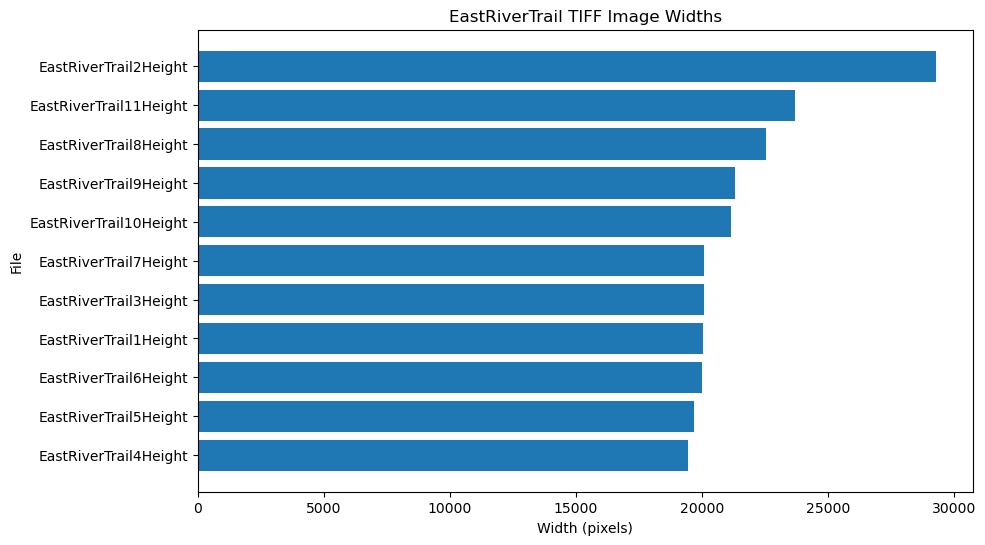

Min:  ('EastRiverTrail10Height', 21165) 
 Max:  ('EastRiverTrail9Height', 21336)


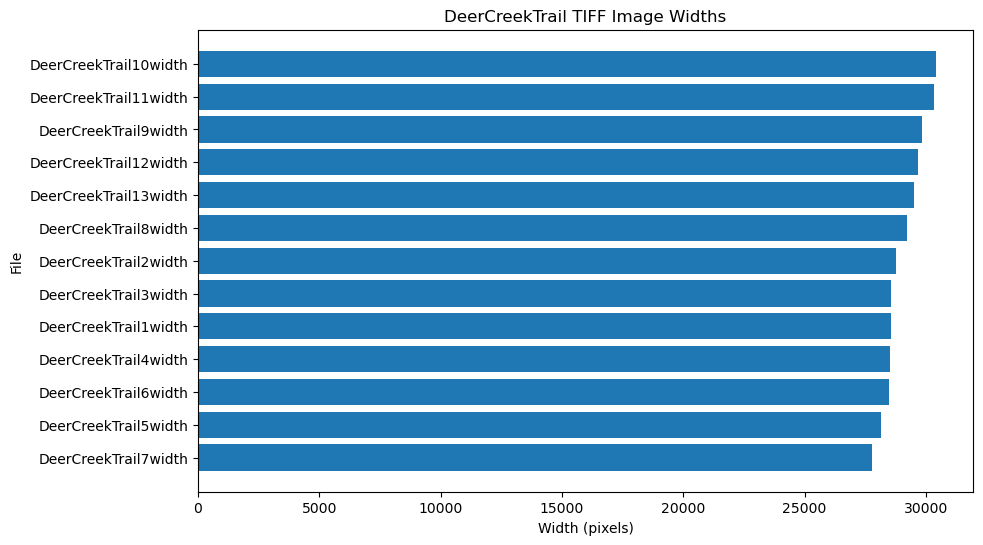

Min:  ('DeerCreekTrail10width', 30420) 
 Max:  ('DeerCreekTrail9width', 29841)


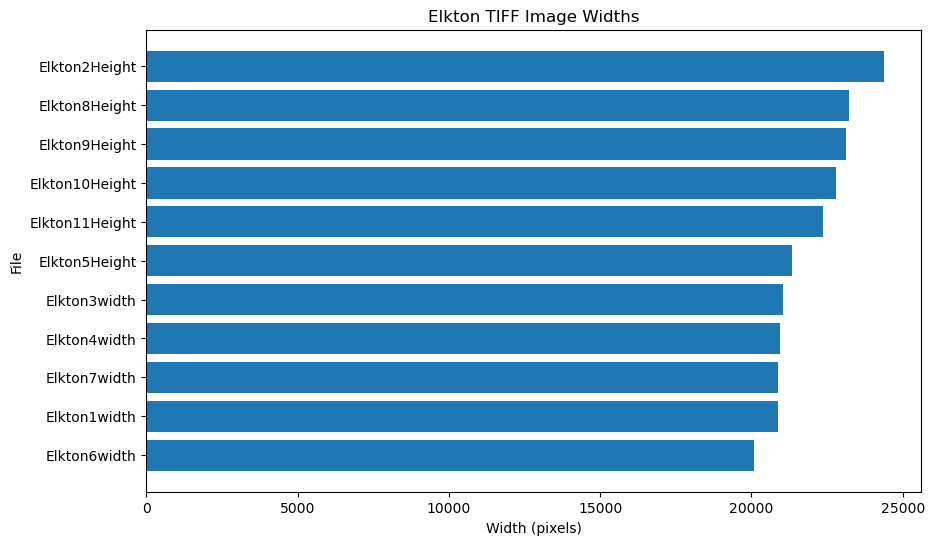

Min:  ('Elkton10Height', 22781) 
 Max:  ('Elkton9Height', 23134)


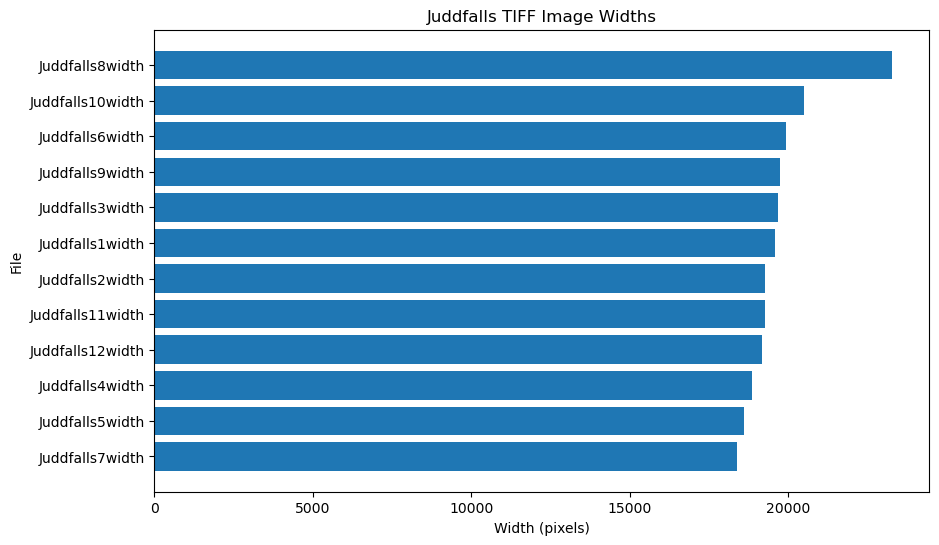

Min:  ('Juddfalls10width', 20491) 
 Max:  ('Juddfalls9width', 19737)


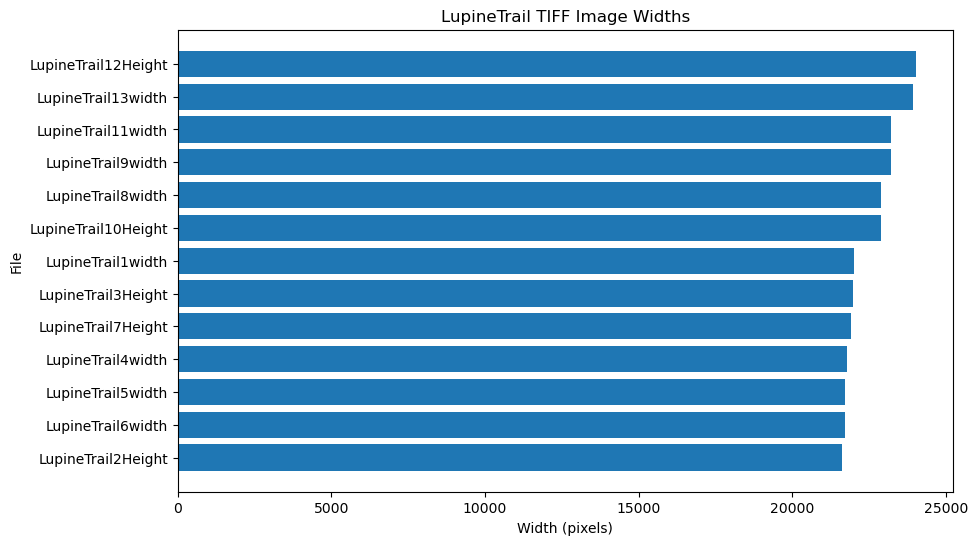

Min:  ('LupineTrail10Height', 22891) 
 Max:  ('LupineTrail9width', 23204)


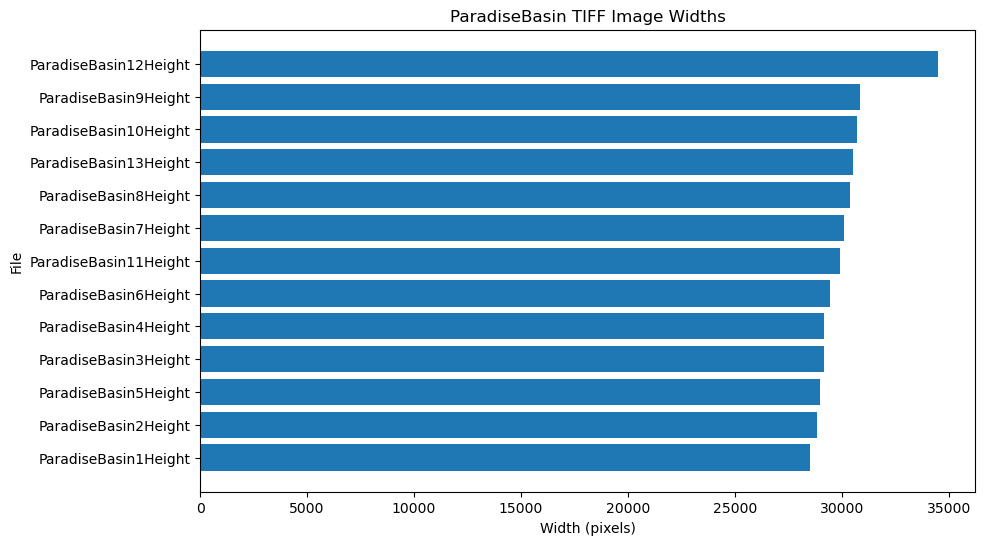

Min:  ('ParadiseBasin10Height', 30718) 
 Max:  ('ParadiseBasin9Height', 30846)


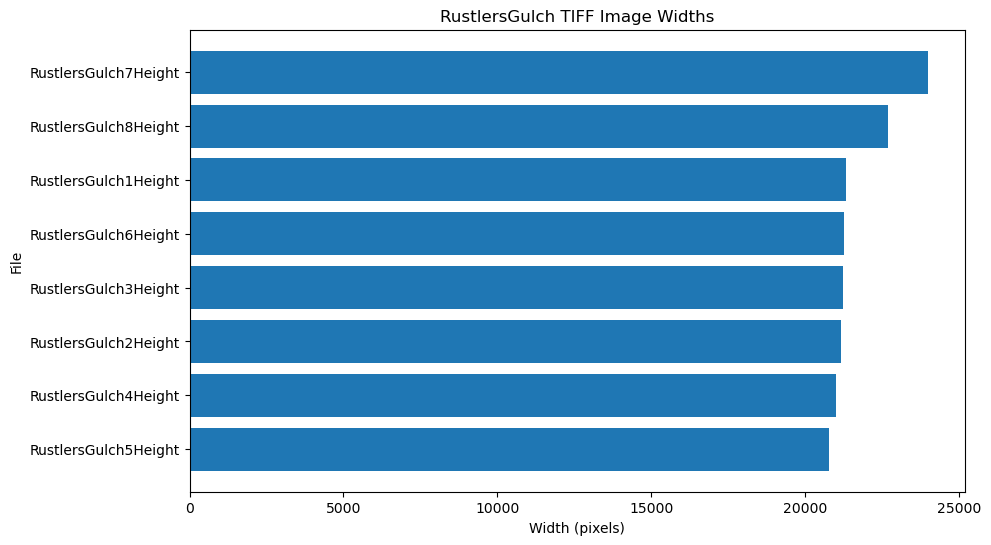

Min:  ('RustlersGulch1Height', 21326) 
 Max:  ('RustlersGulch8Height', 22669)


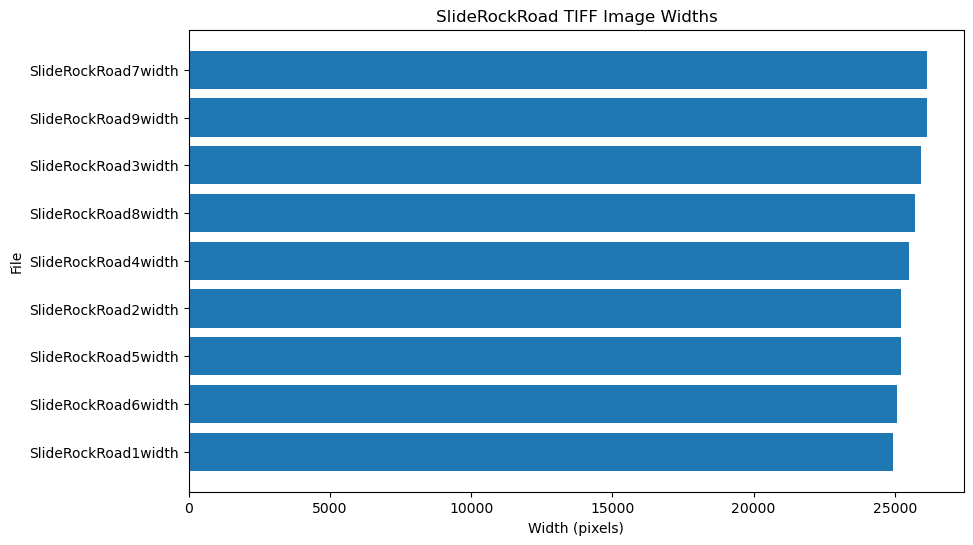

Min:  ('SlideRockRoad1width', 24941) 
 Max:  ('SlideRockRoad9width', 26137)


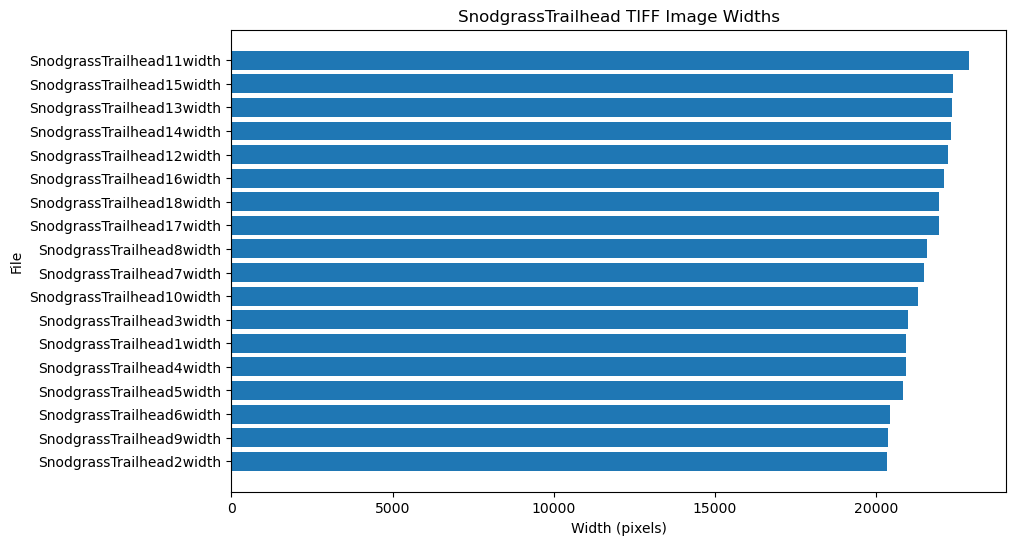

Min:  ('SnodgrassTrailhead10width', 21280) 
 Max:  ('SnodgrassTrailhead9width', 20360)


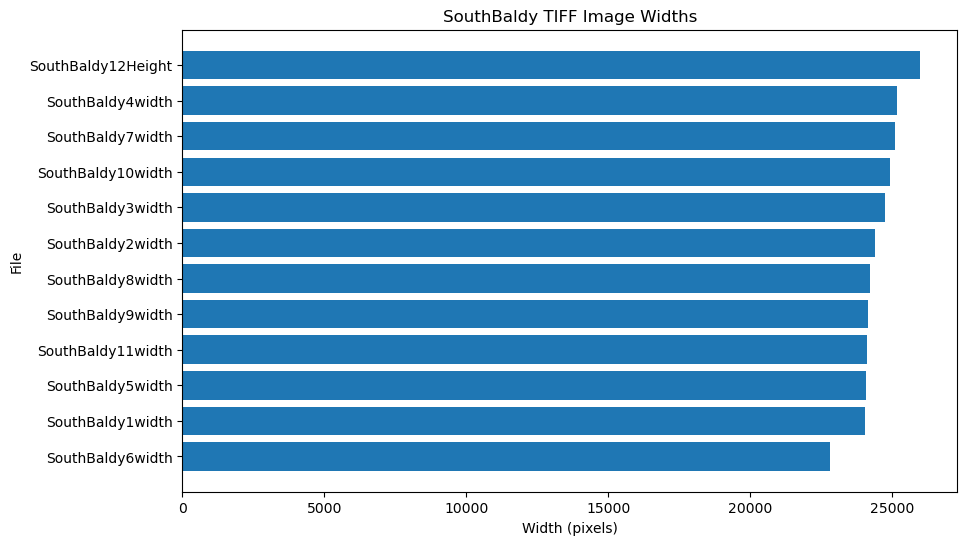

Min:  ('SouthBaldy10width', 24914) 
 Max:  ('SouthBaldy9width', 24143)


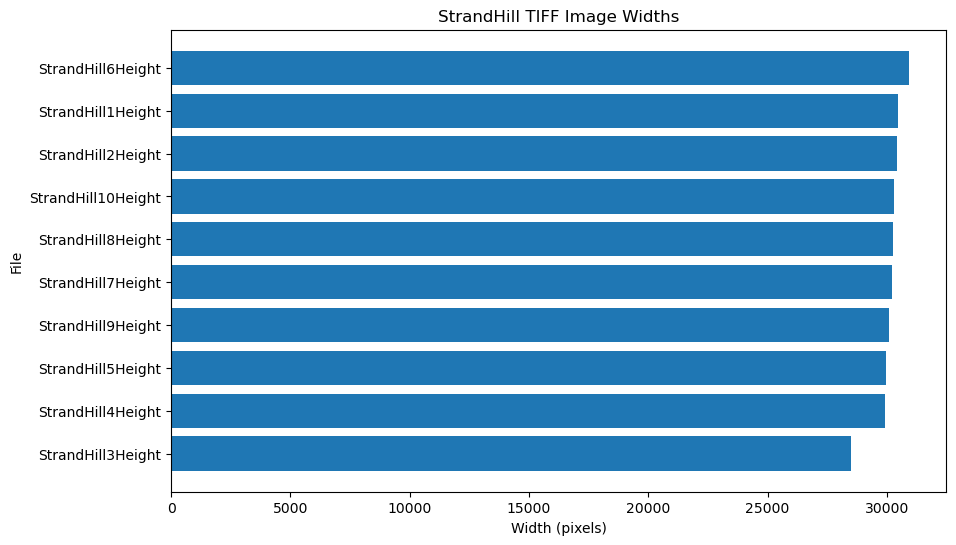

Min:  ('StrandHill10Height', 30320) 
 Max:  ('StrandHill9Height', 30110)


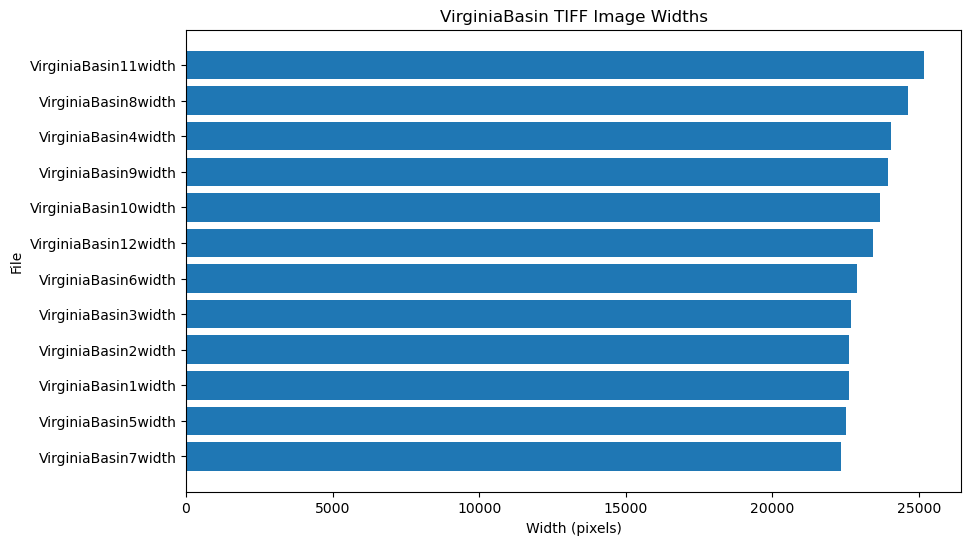

Min:  ('VirginiaBasin10width', 23658) 
 Max:  ('VirginiaBasin9width', 23959)


In [ ]:
directories= ["EastRiverTrail", "DeerCreekTrail", "Elkton", "Juddfalls", "LupineTrail", "ParadiseBasin", "RustlersGulch", "SlideRockRoad", "SnodgrassTrailhead", "SouthBaldy", "StrandHill", "VirginiaBasin"]
# FILE PATH CHANGED used to be:  source_data_dir = "C:/Users/jaydb/Snowpack_Project/2019-2020_Data/Imagery/"
# See top for updated filepaths

for dir in directories:
    widths = get_tiff_widths([dir], IMAGERY_FOLDER)
    if not widths:
        print("No TIFF files found in ", dir)
    else:
        plot_widths(widths, dir)
        print("Min: ", min(widths), "\n", "Max: ",  max(widths))

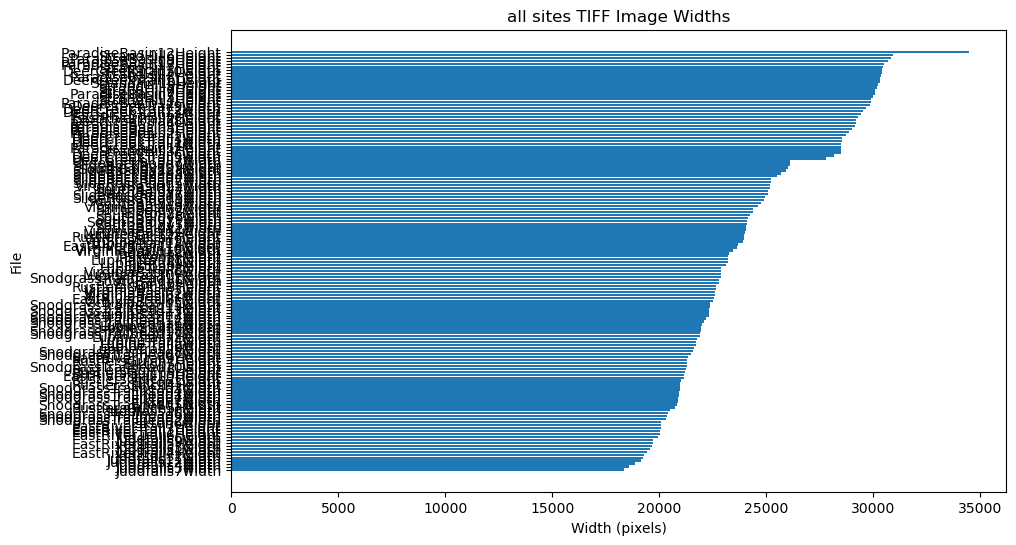

Min:  18362 
 Max:  34503


In [ ]:
# updated source_data_dir = "C:/Users/jaydb/Snowpack_Project/2019-2020_Data/Imagery/" see top for updated filepaths

widths = get_tiff_widths(directories, IMAGERY_FOLDER)
if not widths:
    print("No TIFF files found in the given directories.")
else:
    plot_widths(widths, "all sites")
    widths = list(map(lambda tup: tup[1], widths))
    print("Min: ", min(widths), "\n", "Max: ",  max(widths))

Mean: 24241.00704225352
Median: 23214.5
Min: 18362
Max: 34503


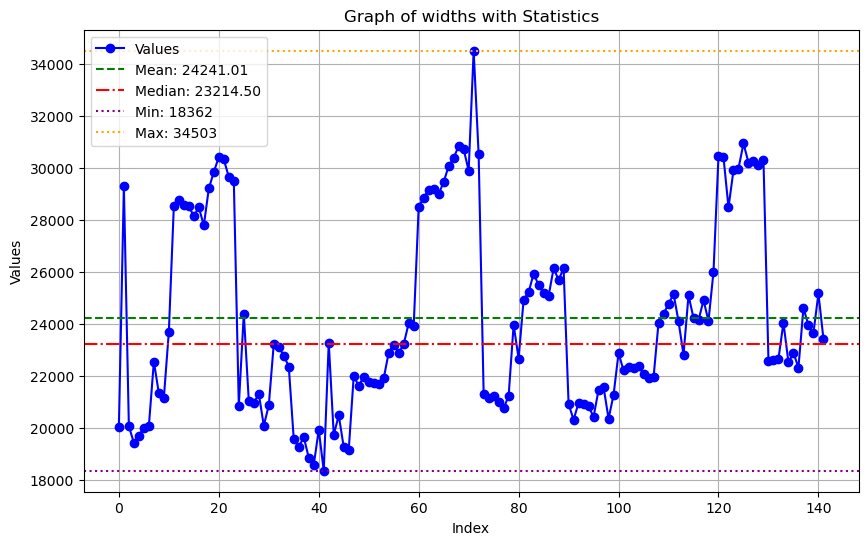

In [11]:
# Calculate statistics
mean = np.mean(widths)
median = np.median(widths)
minimum = np.min(widths)
maximum = np.max(widths)



# Print statistics
print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Min: {minimum}")
print(f"Max: {maximum}")

# Plot the widths
plt.figure(figsize=(10, 6))
plt.plot(widths, marker='o', linestyle='-', color='b', label='Values')
plt.axhline(mean, color='g', linestyle='--', label=f'Mean: {mean:.2f}')
plt.axhline(median, color='r', linestyle='-.', label=f'Median: {median:.2f}')
plt.axhline(minimum, color='purple', linestyle=':', label=f'Min: {minimum}')
plt.axhline(maximum, color='orange', linestyle=':', label=f'Max: {maximum}')

# Add labels and legend
plt.title("Graph of widths with Statistics")
plt.xlabel("Index")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()


Visualize Original Mask overlayed with original image

Image shape: (3, 23953, 28571), dtype=float32
Mask shape:  (1, 23953, 28571), dtype=float32
Super imposed image saved to: C:/Users/jaydb/Snowpack_Project/Super_imposed_Images\DeerCreekTrail_2019_05_30_snow_superimposed.tif


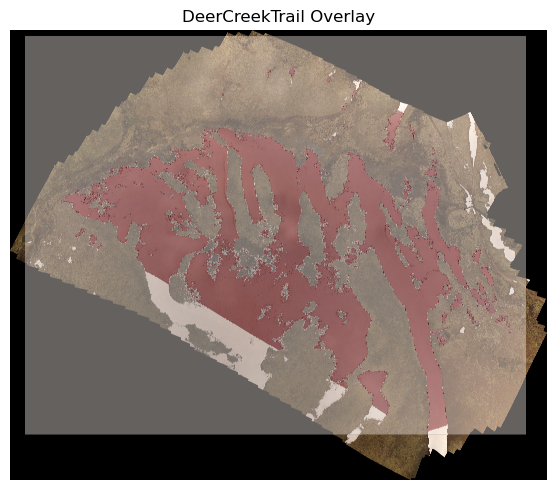

In [ ]:
# -------------------------------
# Jayden Version
image_tif_path = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_30_snow.tif"
mask_tif_path  = r"C:\Users\jaydb\Snowpack_Project\Upscaled_Masks\Snow_Mask\DeerCreekTrail\DeerCreekTrail_2019_05_30_snowbinary.tif"

visualize_tif_image_and_mask(image_tif_path, mask_tif_path, title="DeerCreekTrail Overlay")

Image shape: (3, 23953, 28571), dtype=float32
Mask shape:  (1, 23953, 28571), dtype=float32
Super imposed image saved to: C:/Users/jaydb/Snowpack_Project/Super_imposed_Images\DeerCreekTrail_2019_05_30_snow_superimposed.tif


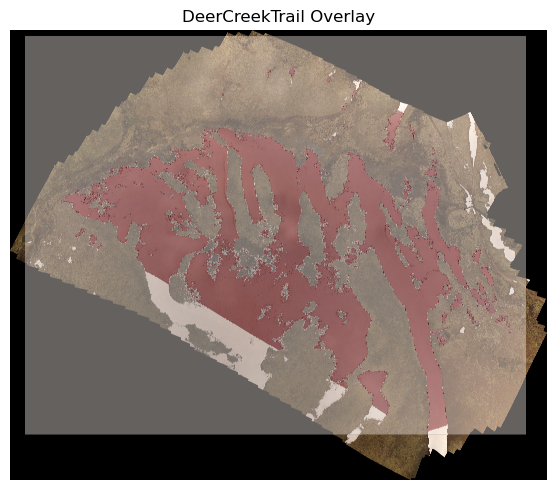

In [ ]:
# -------------------------------
# Joel Version (Globalish) using instatiated paths
image_tif_path = IMAGERY_FOLDER / "DeerCreekTrail" / "DeerCreekTrail_2019_05_30_snow.tif"
mask_tif_path  = SOURCE_FILEPATH / "Upscaled_Masks" / "Snow_Mask" / "DeerCreekTrail" / "DeerCreekTrail_2019_05_30_snowbinary.tif"

visualize_tif_image_and_mask(image_tif_path, mask_tif_path, title="DeerCreekTrail Overlay")

Checking number of channels per image

In [ ]:
# Example usage for Joel filepaths:
check_tiff_channels_recursive( IMAGERY_FOLDER, visualize_fourth=False)

File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_11_snow.tif
  Shape: (23846, 28546, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif
  Shape: (23898, 28759, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_30_snow.tif
  Shape: (23953, 28571, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_07_snow.tif
  Shape: (23142, 28517, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_13_snow.tif
  Shape: (22716, 28153, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_19_snow.tif
  Shape: (22458, 28481, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Proj

In [ ]:
# Example usage:

root_dir = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery"
check_tiff_channels_recursive(root_dir, visualize_fourth=False)

File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_11_snow.tif
  Shape: (23846, 28546, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_22_snow.tif
  Shape: (23898, 28759, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_05_30_snow.tif
  Shape: (23953, 28571, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_07_snow.tif
  Shape: (23142, 28517, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_13_snow.tif
  Shape: (22716, 28153, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2019_06_19_snow.tif
  Shape: (22458, 28481, 3)
  Detected Channels: 3
File: C:\Users\jaydb\Snowpack_Proj

Visualize NaN and "No Data" labeled pixels from original images

Opened C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\SnodgrassTrailhead\SnodgrassTrailhead_2020_05_06_snow.tif
 nodata: 0.0


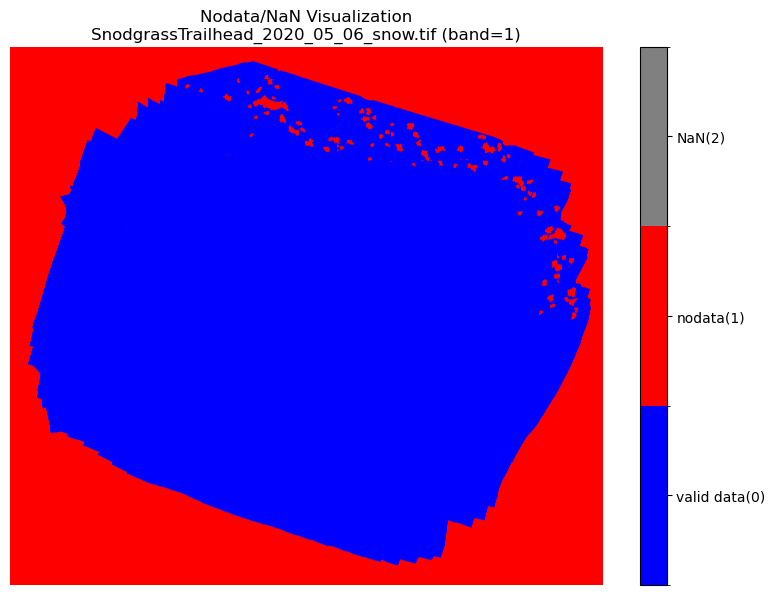

In [14]:
tiff_file = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\SnodgrassTrailhead\SnodgrassTrailhead_2020_05_06_snow.tif"
visualize_nodata_and_nan(tiff_file, band_index=1)

Opened C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\SnodgrassTrailhead\SnodgrassTrailhead_2020_05_06_snow.tif
 nodata: 0.0


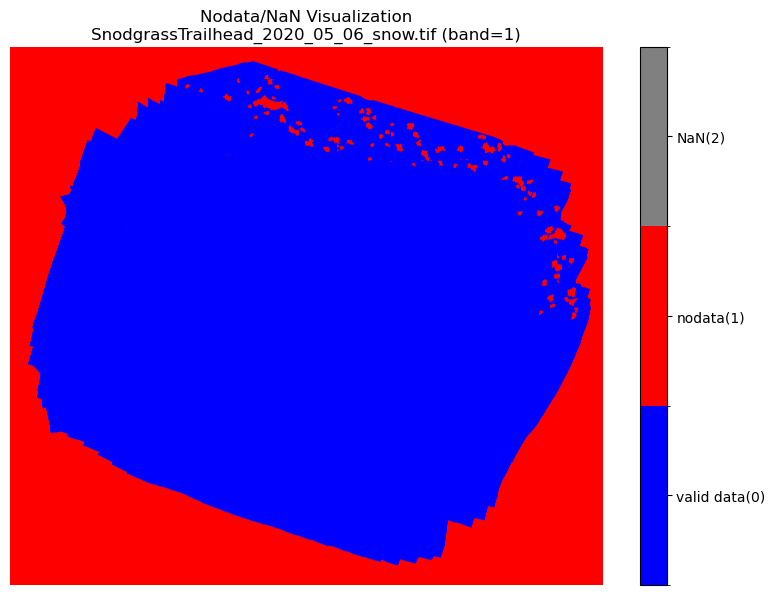

In [ ]:
# Joel File version
tiff_file = IMAGERY_FOLDER / "SnodgrassTrailhead" / "SnodgrassTrailhead_2020_05_06_snow.tif"
visualize_nodata_and_nan(tiff_file, band_index=1)

Opened C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2020_05_12_snow.tif
 nodata: 0.0


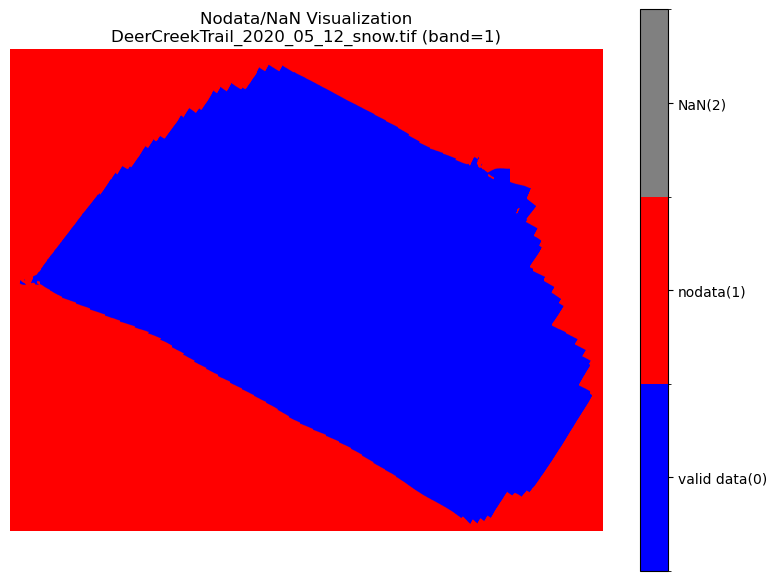

In [15]:
tiff_file = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\DeerCreekTrail\DeerCreekTrail_2020_05_12_snow.tif"
visualize_nodata_and_nan(tiff_file, band_index=1)

In [12]:
img_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0156_img.npy"
msk_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0156_msk.npy"
debug_tile_pair(img_path, msk_path)


=== Analyzing tile pair ===
Image tile path: C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0156_img.npy
Mask tile path : C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0156_msk.npy

--- Image Tile ---
raw shape: (3, 512, 512)
Detected channels-first format (C,H,W).
image tile stats =>  #NaN=0, min=0.0, max=1.0, mean=0.3456059396266937

--- Mask Tile ---
raw shape: (1, 512, 512)
mask stats => total=262144, #NaN=0, #-3.4e38=0
             #zeros=254231, #ones=7913, valid_ratio=1.0000
unique mask values (excluding NaN/-3.4e38): [0. 1.]

--- Summary ---
Mask has 100% valid [0 or 1]. No NaNs or weird values found in the mask.
No NaNs in the image tile array.
Done.



In [13]:
img_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0226_img.npy"
msk_path = r"C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0226_msk.npy"
debug_tile_pair(img_path, msk_path)


=== Analyzing tile pair ===
Image tile path: C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0226_img.npy
Mask tile path : C:\Users\jaydb\Snowpack_Project\Tiled_Output\DeerCreekTrail_2019_05_22_snow__tile_0226_msk.npy

--- Image Tile ---
raw shape: (3, 512, 512)
Detected channels-first format (C,H,W).
image tile stats =>  #NaN=0, min=0.0, max=1.0, mean=0.5840654969215393

--- Mask Tile ---
raw shape: (1, 512, 512)
mask stats => total=262144, #NaN=0, #-3.4e38=0
             #zeros=70819, #ones=191325, valid_ratio=1.0000
unique mask values (excluding NaN/-3.4e38): [0. 1.]

--- Summary ---
Mask has 100% valid [0 or 1]. No NaNs or weird values found in the mask.
No NaNs in the image tile array.
Done.



Printing the currently set "nodata" value for each original image

In [20]:
base_folder = r"C:\Users\jaydb\UCB-O365\Travis Hainsworth - RMBL\2 - Source Data\2019-2020_Data\Imagery"
list_nodata_in_all_subfolders(base_folder, mask_pattern="*_snow.tif")


=== Location: DeerCreekTrail ===
  DeerCreekTrail_2019_05_11_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_05_22_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_05_30_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_06_07_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_06_13_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_06_19_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2019_07_02_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2020_05_05_snow.tif: nodata=None (no nodata set)
  DeerCreekTrail_2020_05_12_snow.tif: nodata=0.0
  DeerCreekTrail_2020_05_23_snow.tif: nodata=0.0
  DeerCreekTrail_2020_05_28_snow.tif: nodata=0.0
  DeerCreekTrail_2020_06_04_snow.tif: nodata=0.0
  DeerCreekTrail_2020_06_13_snow.tif: nodata=0.0

=== Location: EastRiverTrail ===
  EastRiverTrail_2019_05_03_snow.tif: nodata=None (no nodata set)
  EastRiverTrail_2019_05_08_snow.tif: nodata=None (no nodata set)
  EastRiverTrail_2019_05_12

Set all "nodata" values to None for all photos

In [ ]:
def remove_nodata_value(tiff_path):
    with rasterio.open(tiff_path, 'r+', IGNORE_COG_LAYOUT_BREAK = True) as dataset:
        # Check current NoData value
        print(f"Current NoData: {dataset.nodata}")

        # If NoData is 0, set it to None
        if dataset.nodata == None:
            dataset.nodata = 0.0
            print(f"Updated NoData to: {dataset.nodata}")
            

In [ ]:
directory = r"C:\Users\jaydb\Snowpack_Project\2019-2020_Data\Imagery\VirginiaBasin"
tiff_files = glob.glob(os.path.join(directory, "*.tif"))

# Loop through and process each file
for tiff_file in tiff_files:
    remove_nodata_value(tiff_file)

print("Processing complete!")